# Hypothesis check: NN vs GBDT benchmark

This notebook tests the four hypotheses from the reference figure on our benchmark:

1. Larger **dataset size** (`n`) is associated with larger `delta_norm` (NN worse vs GBDT).
2. Larger **instance-to-attribute ratio** (`n_over_d`) is associated with larger `delta_norm`.
3. Larger **median canonical correlation** (`pymfe__can_cor.median`) is associated with smaller `delta_norm`.
4. Larger **minimum class frequency** (`pymfe__freq_class.min`) is associated with smaller `delta_norm`.

`delta_norm = best_a_norm_error - best_b_norm_error`, so positive values mean the NN group performs worse than GBDT.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_dir = notebook_dir.parent
repo_root = project_dir.parent

sys.path.insert(0, str(project_dir / "src"))
sys.path.insert(0, str(repo_root / "tabarena" / "tabarena"))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

from mfa.config import parse_config
from mfa.pipeline import run_analysis

sns.set_theme(style="ticks", context="talk")

raw_config = yaml.safe_load((project_dir / "configs" / "default.yaml").read_text())

# Include pymfe features required by the hypotheses.
raw_config["metafeatures"]["feature_sets"] = ["basic", "pymfe"]
raw_config["metafeatures"]["pymfe_groups"] = ["general", "statistical", "info-theory"]
raw_config["metafeatures"]["pymfe_summary"] = ["mean", "sd", "median", "min", "max"]

# Use two-sided p-values so both positive and negative hypotheses can be tested.
raw_config["comparisons"][0]["expected_direction"] = None

# CI bootstrapping is optional and expensive for full-benchmark runs.
raw_config["statistics"]["confidence_interval"] = False

config = parse_config(raw_config)

/work/mherre/tabular-meta-feature-analysis/tabarena/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-16 12:12:37,546	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
datasets = [
    "qsar-biodeg"
]  # None = all benchmark datasets. Use a short list for faster smoke tests.
result = run_analysis(config, datasets=datasets)

analysis = result.analysis_table.copy()
corr_df = pd.DataFrame([row.__dict__ for row in result.correlation_results])

if result.correction_result is not None:
    corr_df["p_value_adj"] = result.correction_result.adjusted_p_values
    corr_df["rejected"] = result.correction_result.rejected

analysis.shape, corr_df.shape

WARNING mfa.groups: Group `nn` contains config_types absent from data: MITRA_GPU, TABICLV2, TABICL_GPU, TABPFN-V2.6
/work/mherre/tabular-meta-feature-analysis/tabarena/.venv/lib/python3.11/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/work/mherre/tabular-meta-feature-analysis/tabarena/.venv/lib/python3.11/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'can_cor' with summary 'sd'. Will set it as 'np.nan'.
  warnings.warn(
/work/mherre/tabular-meta-feature-analysis/tabarena/.venv/lib/python3.11/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'g_mean' with summary 'mean'. Will set it as 'np.nan'.
  warnings.warn(
/work/mherre/tabular-meta-feature-analysis/tabarena/.venv/lib/python3.11/site-packages/pymfe/_internal.py:732: RuntimeWarning: Can't summarize feature 'g_mean' with summary 'min'. Will set it as 'np.nan'.


((0, 172), (154, 11))

In [ ]:
hypotheses = pd.DataFrame(
    [
        {"label": "Dataset Size", "predictor": "n", "expected_sign": 1},
        {"label": "Inst-To-Attributes", "predictor": "n_over_d", "expected_sign": 1},
        {
            "label": "Med. Canon.-Corr.",
            "predictor": "pymfe__can_cor.median",
            "expected_sign": -1,
        },
        {
            "label": "Min. Class Freq.",
            "predictor": "pymfe__freq_class.min",
            "expected_sign": -1,
        },
    ]
)

corr_columns = ["predictor", "statistic", "p_value", "n_observations"]
if "p_value_adj" in corr_df.columns:
    corr_columns.append("p_value_adj")

summary = hypotheses.merge(corr_df[corr_columns], on="predictor", how="left")

p_col = "p_value_adj" if "p_value_adj" in summary.columns else "p_value"
summary["observed_sign"] = np.sign(summary["statistic"])
summary["sign_matches"] = summary["observed_sign"] == summary["expected_sign"]
summary["verdict"] = np.where(
    summary["sign_matches"] & (summary[p_col] < 0.05),
    "Supported",
    "Not supported",
)

summary[
    [
        "label",
        "predictor",
        "statistic",
        "p_value",
        *(["p_value_adj"] if "p_value_adj" in summary.columns else []),
        "n_observations",
        "verdict",
    ]
].sort_values("label")

,label,predictor,statistic,p_value,p_value_adj,n_observations,verdict
0,Dataset Size,n,NaN,NaN,NaN,0,Not supported
1,Inst-To-Attributes,n_over_d,NaN,NaN,NaN,0,Not supported
2,Med. Canon.-Corr.,pymfe__can_cor.median,NaN,NaN,NaN,0,Not supported
3,Min. Class Freq.,pymfe__freq_class.min,NaN,NaN,NaN,0,Not supported


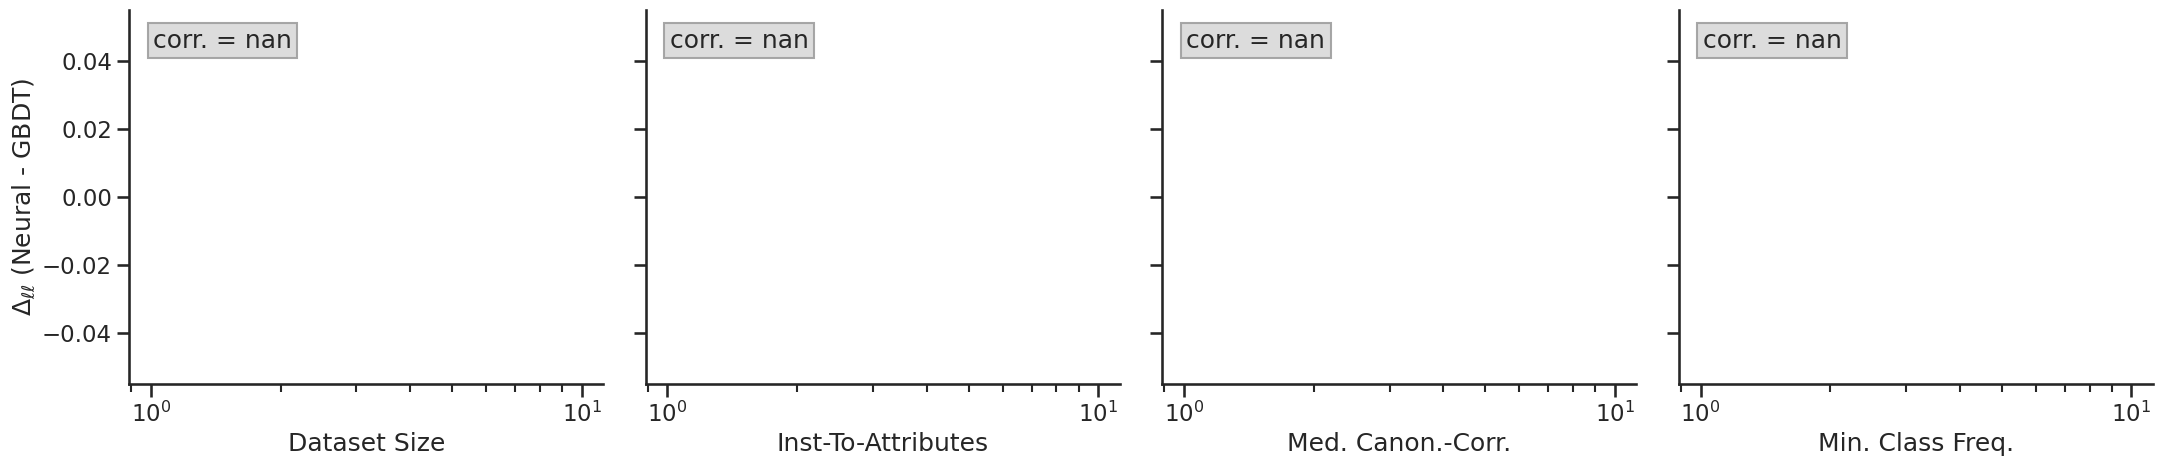

In [5]:
plot_specs = [
    ("n", "Dataset Size"),
    ("n_over_d", "Inst-To-Attributes"),
    ("pymfe__can_cor.median", "Med. Canon.-Corr."),
    ("pymfe__freq_class.min", "Min. Class Freq."),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for ax, (feature, label) in zip(axes, plot_specs):
    plot_df = analysis[[feature, "delta_norm"]].dropna()
    plot_df = plot_df[plot_df[feature] > 0]

    sns.scatterplot(data=plot_df, x=feature, y="delta_norm", s=35, alpha=0.85, ax=ax)
    ax.set_xscale("log")
    ax.set_xlabel(label)

    if ax is axes[0]:
        ax.set_ylabel(r"$\Delta_{\ell\ell}$ (Neural - GBDT)")
    else:
        ax.set_ylabel("")

    row = corr_df.loc[corr_df["predictor"] == feature].iloc[0]
    ax.text(
        0.05,
        0.95,
        f"corr. = {row['statistic']:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        bbox={"facecolor": "#d9d9d9", "edgecolor": "#9e9e9e", "alpha": 0.9},
    )

sns.despine()
fig.tight_layout()
plt.show()